## Importação de Bibliotecas

In [1]:
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Criação de tabelas

In [11]:

PASTA_RASPAGEM = Path('../Raspagem')
PADRAO_ARQUIVO = re.compile(r'dados_aedes_(\d{8})_weekid(\d+)_(\d+)mosquitos')

COLS_MOSQUITO = [
    'aedes_aegypti_femea', 'aedes_aegypti_macho',
    'aedes_albopictus_femea', 'aedes_albopictus_macho',
    'culex_sp_femea', 'culex_sp_macho', 'total_mosquitos'
]

# Mapear arquivos e selecionar o mais atualizado por semana
arquivos = [
    {'arquivo': f, 'data_str': m.group(1), 'week_id': int(m.group(2)), 'n_mosquitos': int(m.group(3))}
    for f in PASTA_RASPAGEM.glob('*.xlsx')
    if (m := PADRAO_ARQUIVO.search(f.name))
]
df_meta = pd.DataFrame(arquivos)
selecionados = df_meta.loc[df_meta.groupby('week_id')['n_mosquitos'].idxmax()]

# Ler e concatenar arquivos selecionados
frames = []
for _, row in selecionados.iterrows():
    df = pd.read_excel(row['arquivo'])
    df['week_id']       = row['week_id']
    df['data_raspagem'] = pd.to_datetime(row['data_str'], format='%Y%m%d')
    frames.append(df)

# Agregar por week_id
df_all = pd.concat(frames, ignore_index=True)
df_all['mes'] = df_all['data_raspagem'].dt.month
df_all['ano'] = df_all['data_raspagem'].dt.year

df_final = (
    df_all
    .groupby(['week_id', 'data_raspagem', 'mes', 'ano'], as_index=False)[COLS_MOSQUITO]
    .sum()
    .sort_values('week_id')
    .reset_index(drop=True)
)


In [13]:
df_final.head()

,week_id,data_raspagem,mes,ano,aedes_aegypti_femea,aedes_aegypti_macho,aedes_albopictus_femea,aedes_albopictus_macho,culex_sp_femea,culex_sp_macho,total_mosquitos
0,450,2025-08-16,8,2025,2,0,0,0,50,10,62
1,451,2025-08-22,8,2025,1,0,0,0,39,2,42
2,452,2025-08-27,8,2025,1,0,0,6,78,7,92
3,453,2025-09-03,9,2025,4,0,0,0,34,7,45
4,454,2025-09-13,9,2025,9,0,0,0,55,10,74


## Distribuição dos Mosquitos ao Longo do Tempo

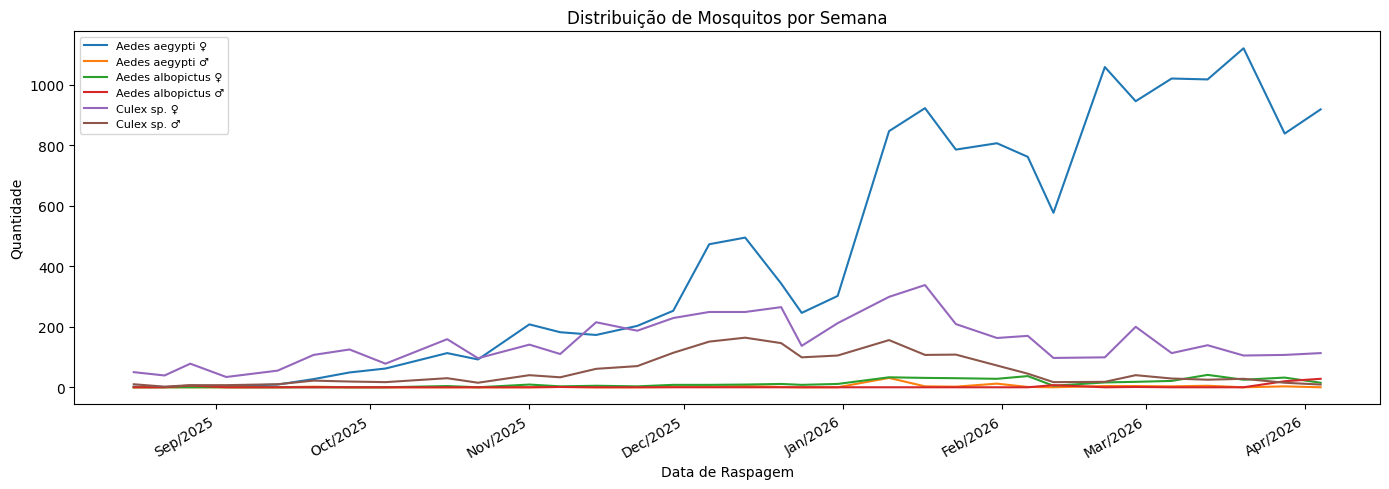

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

especies = {
    'Aedes aegypti ♀':  'aedes_aegypti_femea',
    'Aedes aegypti ♂':  'aedes_aegypti_macho',
    'Aedes albopictus ♀': 'aedes_albopictus_femea',
    'Aedes albopictus ♂': 'aedes_albopictus_macho',
    'Culex sp. ♀':      'culex_sp_femea',
    'Culex sp. ♂':      'culex_sp_macho',
}

for label, col in especies.items():
    ax.plot(df_final['data_raspagem'], df_final[col], label=label)

ax.set_title('Distribuição de Mosquitos por Semana')
ax.set_xlabel('Data de Raspagem')
ax.set_ylabel('Quantidade')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Distribuição dos Mosquitos ao Longo do Tempo (dados_marilia)

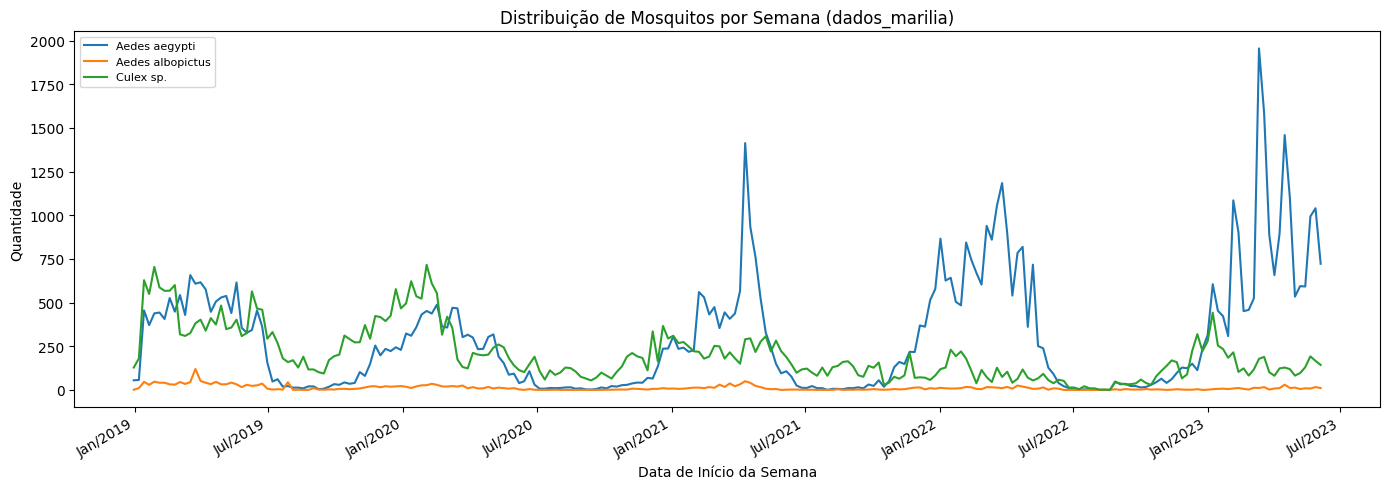

In [20]:

df_marilia = pd.read_csv('../dados_marilia/resumo_analise.csv')
df_marilia['Data Inicio'] = pd.to_datetime(df_marilia['Data Inicio'])

fig, ax = plt.subplots(figsize=(14, 5))

especies_marilia = {
    'Aedes aegypti':    'Aedes aegypti',
    'Aedes albopictus': 'Aedes albopictus',
    'Culex sp.':        'Culex sp',
}

for label, col in especies_marilia.items():
    ax.plot(df_marilia['Data Inicio'], df_marilia[col], label=label)

ax.set_title('Distribuição de Mosquitos por Semana (dados_marilia)')
ax.set_xlabel('Data de Início da Semana')
ax.set_ylabel('Quantidade')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [24]:

MESES = ['janeiro','fevereiro','março','abril','maio','junho',
         'julho','agosto','setembro','outubro','novembro','dezembro']

def fmt_ptbr(d):
    return f"{d.day} de {MESES[d.month - 1]} de {d.year}"

inicio = df_marilia['Data Inicio'].min()
fim    = df_marilia['Data Inicio'].max()
print(f"{fmt_ptbr(inicio)}\naté\n{fmt_ptbr(fim)}")


30 de dezembro de 2018
até
4 de junho de 2023


## Casos de Dengue por Mês — Porto Alegre (2020–2025)


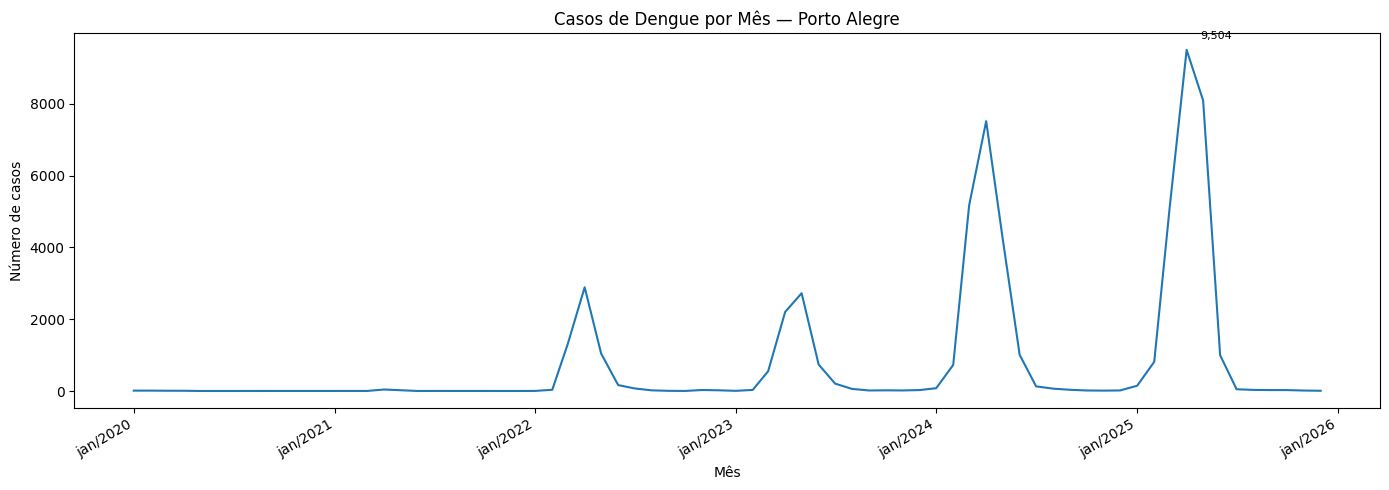

In [27]:
df_dengue = pd.read_csv('../Bases de dados/base_oficial_filtrada_poa/dengue_poa_mensal.csv')
df_dengue['data'] = pd.to_datetime(df_dengue.rename(columns={'ano': 'year', 'mes': 'month'})[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_dengue['data'], df_dengue['casos'])

# Anotação do pico
idx_pico = df_dengue['casos'].idxmax()
pico = df_dengue.loc[idx_pico]
ax.annotate(
    f"{int(pico['casos']):,}",
    xy=(pico['data'], pico['casos']),
    xytext=(10, 8), textcoords='offset points',
    fontsize=8
)

ax.set_title('Casos de Dengue por Mês — Porto Alegre')
ax.set_xlabel('Mês')
ax.set_ylabel('Número de casos')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Sobreposição: Mosquitos Capturados × Casos Confirmados de Dengue

Agrega os dados semanais de mosquitos para mensal e sobrepõe com os casos oficiais de dengue de Porto Alegre.  
Dois eixos Y: esquerdo para mosquitos, direito para casos de dengue.


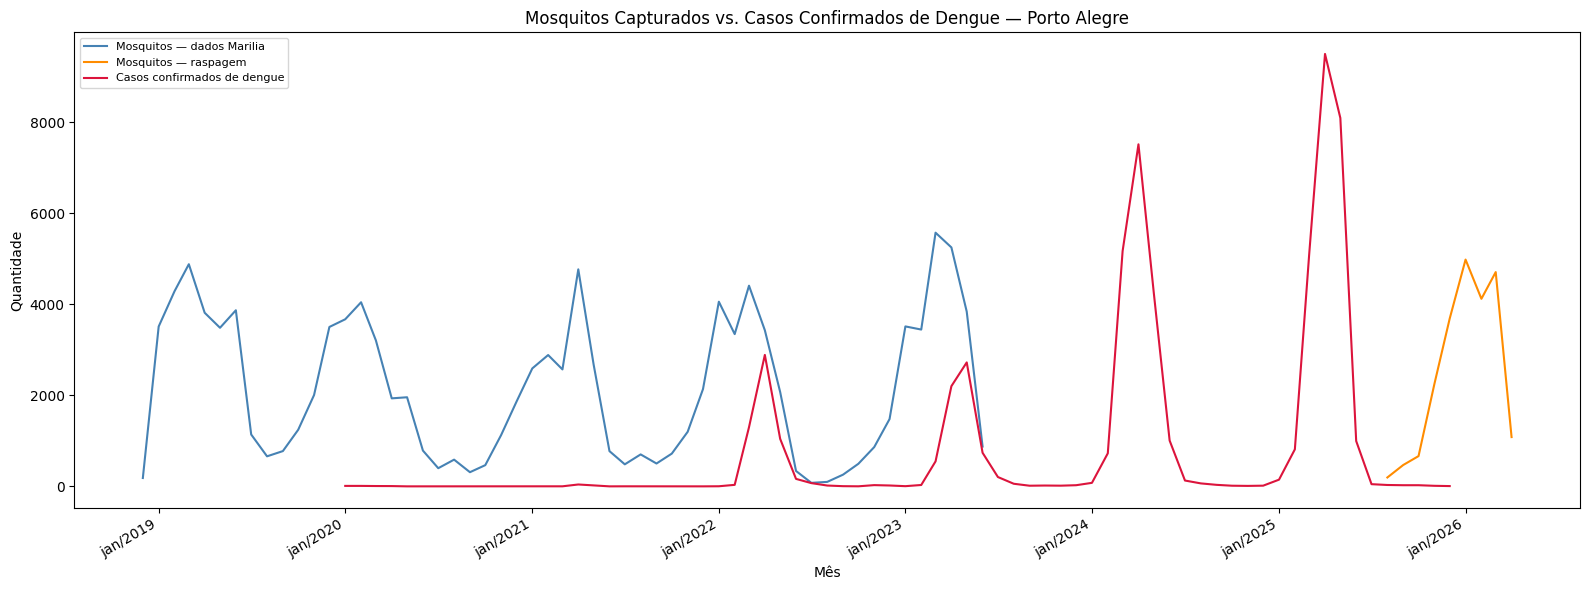

In [29]:
# --- Agregar raspagem para mensal ---
df_final_mensal = (
    df_final
    .assign(ano=df_final['data_raspagem'].dt.year,
            mes=df_final['data_raspagem'].dt.month)
    .groupby(['ano', 'mes'], as_index=False)['total_mosquitos']
    .sum()
)
df_final_mensal['data'] = pd.to_datetime(
    df_final_mensal.rename(columns={'ano': 'year', 'mes': 'month'})[['year', 'month']].assign(day=1)
)

# --- Agregar dados_marilia para mensal ---
df_marilia_mensal = (
    df_marilia
    .assign(ano=df_marilia['Data Inicio'].dt.year,
            mes=df_marilia['Data Inicio'].dt.month)
    .groupby(['ano', 'mes'], as_index=False)[['Aedes aegypti', 'Aedes albopictus', 'Culex sp']]
    .sum()
)
df_marilia_mensal['total'] = (
    df_marilia_mensal['Aedes aegypti'] +
    df_marilia_mensal['Aedes albopictus'] +
    df_marilia_mensal['Culex sp']
)
df_marilia_mensal['data'] = pd.to_datetime(
    df_marilia_mensal.rename(columns={'ano': 'year', 'mes': 'month'})[['year', 'month']].assign(day=1)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df_marilia_mensal['data'], df_marilia_mensal['total'],
        color='steelblue', label='Mosquitos — dados Marilia')
ax.plot(df_final_mensal['data'], df_final_mensal['total_mosquitos'],
        color='darkorange', label='Mosquitos — raspagem')
ax.plot(df_dengue['data'], df_dengue['casos'],
        color='crimson', label='Casos confirmados de dengue')

ax.set_title('Mosquitos Capturados vs. Casos Confirmados de Dengue — Porto Alegre')
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


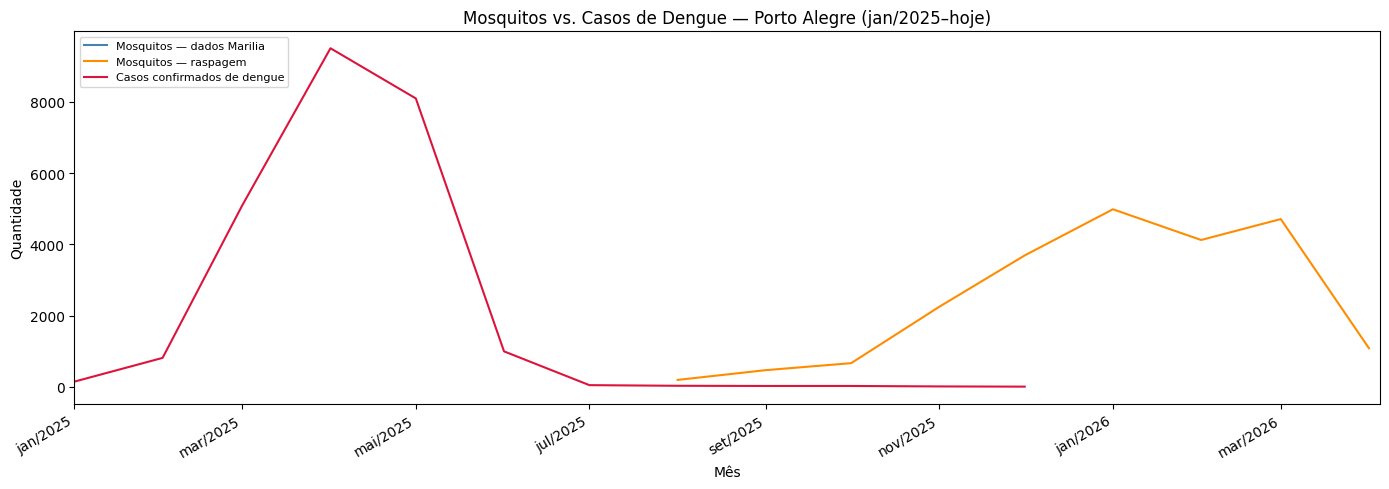

In [30]:
ZOOM_INICIO = pd.Timestamp('2025-01-01')
ZOOM_FIM    = pd.Timestamp.today()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_marilia_mensal['data'], df_marilia_mensal['total'],
        color='steelblue', label='Mosquitos — dados Marilia')
ax.plot(df_final_mensal['data'], df_final_mensal['total_mosquitos'],
        color='darkorange', label='Mosquitos — raspagem')
ax.plot(df_dengue['data'], df_dengue['casos'],
        color='crimson', label='Casos confirmados de dengue')

ax.set_xlim(ZOOM_INICIO, ZOOM_FIM)
ax.set_title('Mosquitos vs. Casos de Dengue — Porto Alegre (jan/2025–hoje)')
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
